In [2]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(123)

In [8]:
df = pd.read_csv('data/fmnist_6000.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 35.9 MB


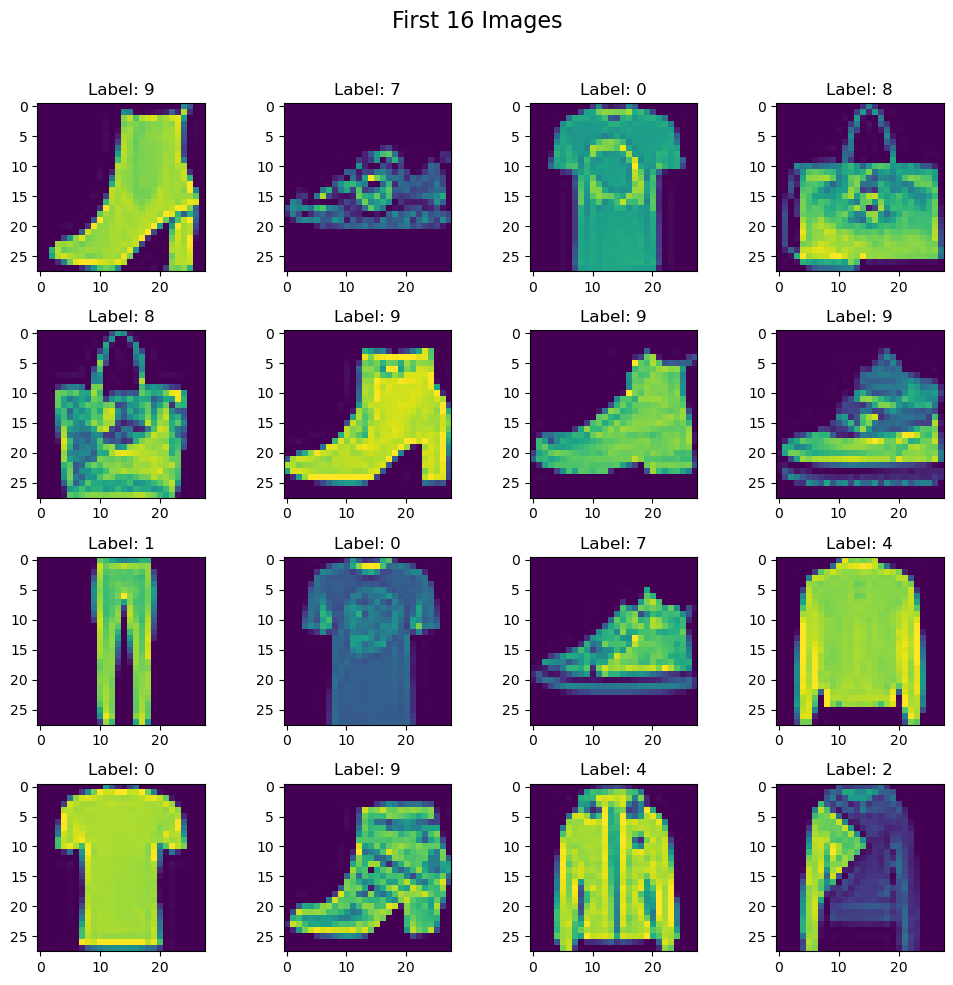

In [13]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)
    # ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [14]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [15]:
X

array([[  0,   0,   0, ..., 165,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(6000, 784))

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [18]:
# scaling the feautures
X_train = X_train/255.0  ## 255 as maximum value is 2555
X_test = X_test/255.0

In [19]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

In [22]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [23]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0431,
         0.0902, 0.5922, 0.6078, 0.4118, 0.3765, 0.4235, 0.4549, 0.5725, 0.5725,
         0.0627, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1294, 0.3961,
         0.3765, 0.3333, 0.3922, 0.5608, 0.4627, 0.5529, 0.5490, 0.4824, 0.4745,
         0.2980, 0.3059, 0.3765, 0.3137, 0.0784, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4745,
         0.3451, 0.2941, 0.3176, 0.2784, 0.2275, 0.2078, 0.1569, 0.1412, 0.1490,
         0.1569, 0.2471, 0.2980, 0.2941, 0.3176, 0.3451, 0.0235, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1961,
         0.5020, 0.2784, 0.3255, 0.2941, 0.2863, 0.3529, 0.3255, 0.2667, 0.2745,
         0.2745, 0.2863, 0.2784, 0.2863, 0.2980, 0.2471, 0.3451, 0.2000, 0.0000,
         0.0000, 0.0000, 0.0

In [39]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # dont shuffle on test as during prediction the calulation accuracy might get affected 

In [33]:
# define NN class

class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)  # last layer 10 output as mfminist has 10 calssifications
    )

  def forward(self, x):

    return self.model(x)

In [50]:
# set learning rate and epochs
epochs = 300
learning_rate = 0.1

In [51]:
# instatiate the model
model = MyNN(X_train.shape[1])

# loss function
criterion = nn.CrossEntropyLoss() # explicitly added softmax (dont have to add in the last layer)

# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

In [52]:
len(train_loader)

150

In [53]:
150*32

4800

In [54]:
# training loop

losses = [] 

for epoch in tqdm(range(epochs)):
    
    total_epoch_loss = 0
    
    for batch_features, batch_labels in train_loader:
        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()
    avg_loss = total_epoch_loss/len(train_loader)
    losses.append(avg_loss)
    #print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


100%|██████████████████████████████████████████████████████████| 300/300 [00:16<00:00, 18.43it/s]


In [46]:
print(avg_loss)

3.428353571204449e-05


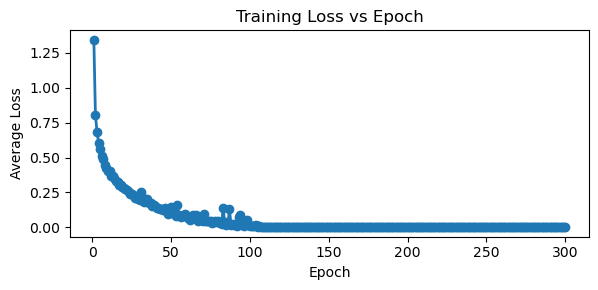

In [65]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, epochs+1), losses, 'o-', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss vs Epoch')
plt.tight_layout()
plt.show()

In [66]:
# set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [76]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        print(outputs.shape)
        _, predicted = torch.max(outputs, 1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([16, 10])
0.8616666666666667


In [67]:
torch.max(outputs, 1)

torch.return_types.max(
values=tensor([17.1818, 36.1345, 54.9932, 23.4817, 39.5934, 57.2869, 76.4162, 48.5111,
        33.2669, 33.1466, 20.9860, 43.8411, 20.2662, 24.2767, 12.5075, 29.0608]),
indices=tensor([4, 8, 9, 6, 8, 1, 1, 0, 5, 5, 5, 1, 6, 8, 6, 8]))

In [77]:
outputs.shape ## last batch is not 32 

torch.Size([16, 10])

In [75]:
torch.max(outputs)

tensor(76.4162)